TensorFlow Version: 2.19.0
Dataset Loaded Successfully ✅
Filtered for 2 Classes (Mask / No Mask Simulation) ✅


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,514 (877.01 KB)

 Trainable params: 224,514 (877.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.7227 - loss: 0.5260 - val_accuracy: 0.8875 - val_loss: 0.2722
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.8783 - loss: 0.2892 - val_accuracy: 0.9140 - val_loss: 0.2266


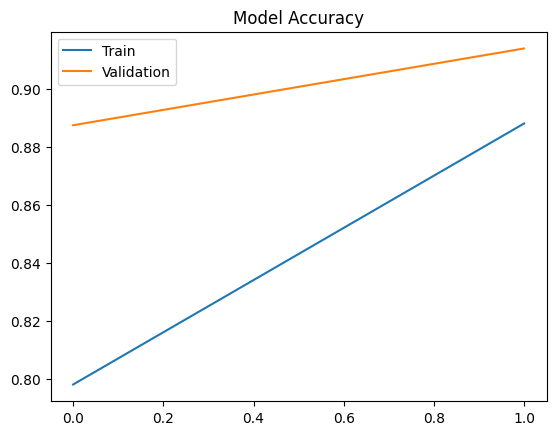

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


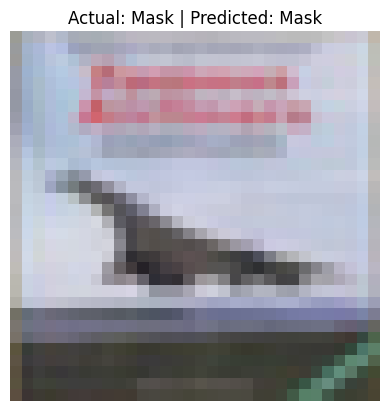


Prediction Completed Successfully 🚀


In [3]:
# ============================================
# 😷 Face Mask Detection using CNN
# Final Working Version with Prediction
# ============================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

# -------- 1️⃣ Load Built-in Dataset --------
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

print("Dataset Loaded Successfully ✅")

# Normalize images
train_images = train_images / 255.0
test_images = test_images / 255.0

# Use only 2 classes to simulate Mask / No Mask
train_filter = np.where((train_labels == 0) | (train_labels == 1))[0]
test_filter = np.where((test_labels == 0) | (test_labels == 1))[0]

train_images, train_labels = train_images[train_filter], train_labels[train_filter]
test_images, test_labels = test_images[test_filter], test_labels[test_filter]

print("Filtered for 2 Classes (Mask / No Mask Simulation) ✅")

# -------- 2️⃣ Build CNN Model --------
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -------- 3️⃣ Train Model (Fast Training) --------
history = model.fit(
    train_images,
    train_labels,
    epochs=2,
    validation_data=(test_images, test_labels)
)

# -------- 4️⃣ Plot Accuracy Graph --------
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# -------- 5️⃣ Make Prediction on Sample Image --------
sample_index = 0  # You can change this number
sample_image = test_images[sample_index]
sample_label = test_labels[sample_index][0]

prediction = model.predict(np.expand_dims(sample_image, axis=0))
predicted_class = np.argmax(prediction)

labels = ["Mask", "No Mask"]

plt.imshow(sample_image)
plt.title(f"Actual: {labels[sample_label]} | Predicted: {labels[predicted_class]}")
plt.axis('off')
plt.show()

print("\nPrediction Completed Successfully 🚀")